# Instrument definition

In [ ]:
%matplotlib inline
import numpy as np
import mcstasscript as ms

ess_w7 = ms.McStas_instr(
    "ESS_butterfly_W7",
    author="Bing Li",
    origin="DMSC",
    input_path="./ESS_butterfly_W7",
    output_path="./ESS_butterfly_W7/out",
)

# Declare section

In [2]:
frac = ess_w7.add_declare_var(
    "double",
    "frac",
    value=0.3,
    comment="Used in the Source component. Defines the statistical fraction of events"
    + "emitted from the cold part of the moderator, the value is determined later in the file"
    + " depending on the moderator type that was chosen",
)

# Initialize section

In [3]:
ess_w7.show_variables()

DECLARE VARIABLES 
type    variable name  array length  value  
------------------------------------------
double  frac                         0.3    



# Trace section

In [4]:
source = ess_w7.add_component(name="source", component_name="ESS_butterfly")
source.set_parameters(
    sector='"W"',
    beamline=7,
    yheight=0.03,  # [m], moderator height, 0.03 to 0.06
    cold_frac=frac,
    # target_index not needed if using dist
    dist=2,  # [m], distance to focusing rectange
    focus_xw=0.095,  # [m], size of focusing rectange
    focus_yh=0.035,
    # c_performance: float = 1.0
    # t_performance: float = 1.0
    Lmin=0.1,  # in Angstrom
    Lmax=10.0,  # in Angstrom
    n_pulses=1,
    acc_power=2,  # [MW]
    # tfocus_dist="position_BW2[2]",  # [m], Position of time focusing window along z axis
    # tfocus_time="tof_BW2",  # [s], position of time focusing window
    # tfocus_width=0.02,  # [s], width of time focusing window
)

In [5]:
# ess_w7.component_help("ESS_butterfly")

In [6]:
width_in, width_out = 0.09, 0.06
start, end = 1.89593, 5.88165
taper_angle = np.degrees(np.arctan((width_in - width_out) / (end - start) / 2))
# taper_angle
position = [(width_in * np.cos(np.radians(taper_angle)) / 2 - 0.047), 0, start]
arm_NBOA = ess_w7.add_component(
    name="arm_NBOA", component_name="Arm", AT=position, ROTATED=[0, -taper_angle, 0]
)
arm_NBOA.set_comment("""
/* =============================================================================
   NBOA - ASYMMETRIC TAPER

   The -x wall of the NBOA is FIXED at -47.000 mm; all of the horizontal
   narrowing (90 -> 60 mm) is taken out of the +x wall, which is the cold
   moderator side. This is the bispectral extraction geometry: the view of the
   thermal face is held constant while the cold-side acceptance is trimmed.

   Consequence: the guide centre-line is NOT the nominal beam axis. It is a
   straight line from -2.0295 mm at 1895.927 mm to -16.8711 mm at 5881.65 mm,
   tilted by -0.213350 deg = half the 0.426695 deg ToO horizontal taper angle.

   Guide_gravity is symmetric about its own axis, but two straight walls are
   reproduced EXACTLY by a symmetric guide placed on their bisector. The tilt is
   identical for all four sections, so one arm carries the whole NBOA and the
   sections hang off it with plain z offsets.

   The -x wall releases at 5.927 m; from Guide_5 onward the guide is symmetric
   about its own axis again, so the tilt is removed there.
============================================================================= */
""")

In [7]:
guide_1 = ess_w7.add_component(
    name="Guide_1",
    component_name="Guide_gravity",
    AT=[0, 0, 0],
    ROTATED=[0, 0, 0],
    RELATIVE=arm_NBOA,
)
guide_1.set_parameters(
    w1=0.089955,
    h1=0.029992,
    w2=0.082455,
    h2=0.034937,
    l=0.999400,
    mleft=1.5,
    mright=1.5,
    mtop=4,
    mbottom=4,
)
guide_1.set_comment("/* -> 1895.927 mm */")

In [8]:
guide_2 = ess_w7.add_component(
    name="Guide_2",
    component_name="Guide_gravity",
    AT=[0, 0, 1.000400],
    ROTATED=[0, 0, 0],
    RELATIVE=arm_NBOA,
)
guide_2.set_parameters(
    w1=0.082447,
    h1=0.034941,
    w2=0.074948,
    h2=0.039160,
    l=0.999200,
    mleft=1.5,
    mright=1.5,
    mtop=4,
    mbottom=4,
)
guide_2.set_comment("/* 1.0 mm gap after Guide_1 */")

In [9]:
guide_3 = ess_w7.add_component(
    name="Guide_3",
    component_name="Guide_gravity",
    AT=[0, 0, 2.000800],
    ROTATED=[0, 0, 0],
    RELATIVE=arm_NBOA,
)
guide_3.set_parameters(
    w1=0.074939,
    h1=0.039164,
    w2=0.063838,
    h2=0.044511,
    l=1.479200,
    mleft=1.5,
    mright=1.5,
    mtop=4,
    mbottom=4,
)
guide_3.set_comment("/* 1.2 mm gap after Guide_2 */")

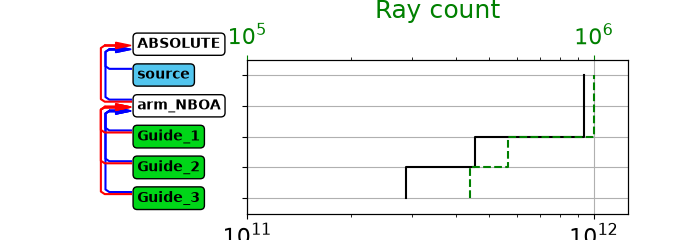

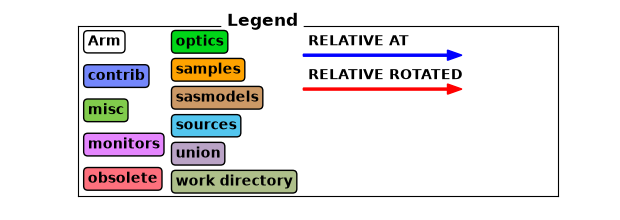

In [10]:
ess_w7.show_diagram(analysis=True)

# Diagnostics

In [11]:
diag = ms.Diagnostics(ess_w7)

diag.settings(ncount=1e7, suppress_output=True, mpi="auto")
diag.show_settings()

Instrument settings:
  ncount:           1.00e+07
  mpi:              auto 
  output_path:      ESS_butterfly_W7/out
  run_path:         ./ESS_butterfly_W7
  package_path:     /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/share/mcstas/resources
  executable_path:  /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/bin
  executable:       mcrun
  force_compile:    True
  NeXus:            False
  save_comp_pars:   False


In [12]:
diag.show_parameters()

No instrument parameters available


In [13]:
diag.clear_points()
diag.add_point(after="source")
diag.add_point(before="Guide_1")
diag.add_point(after="Guide_3")

In [14]:
diag.run()

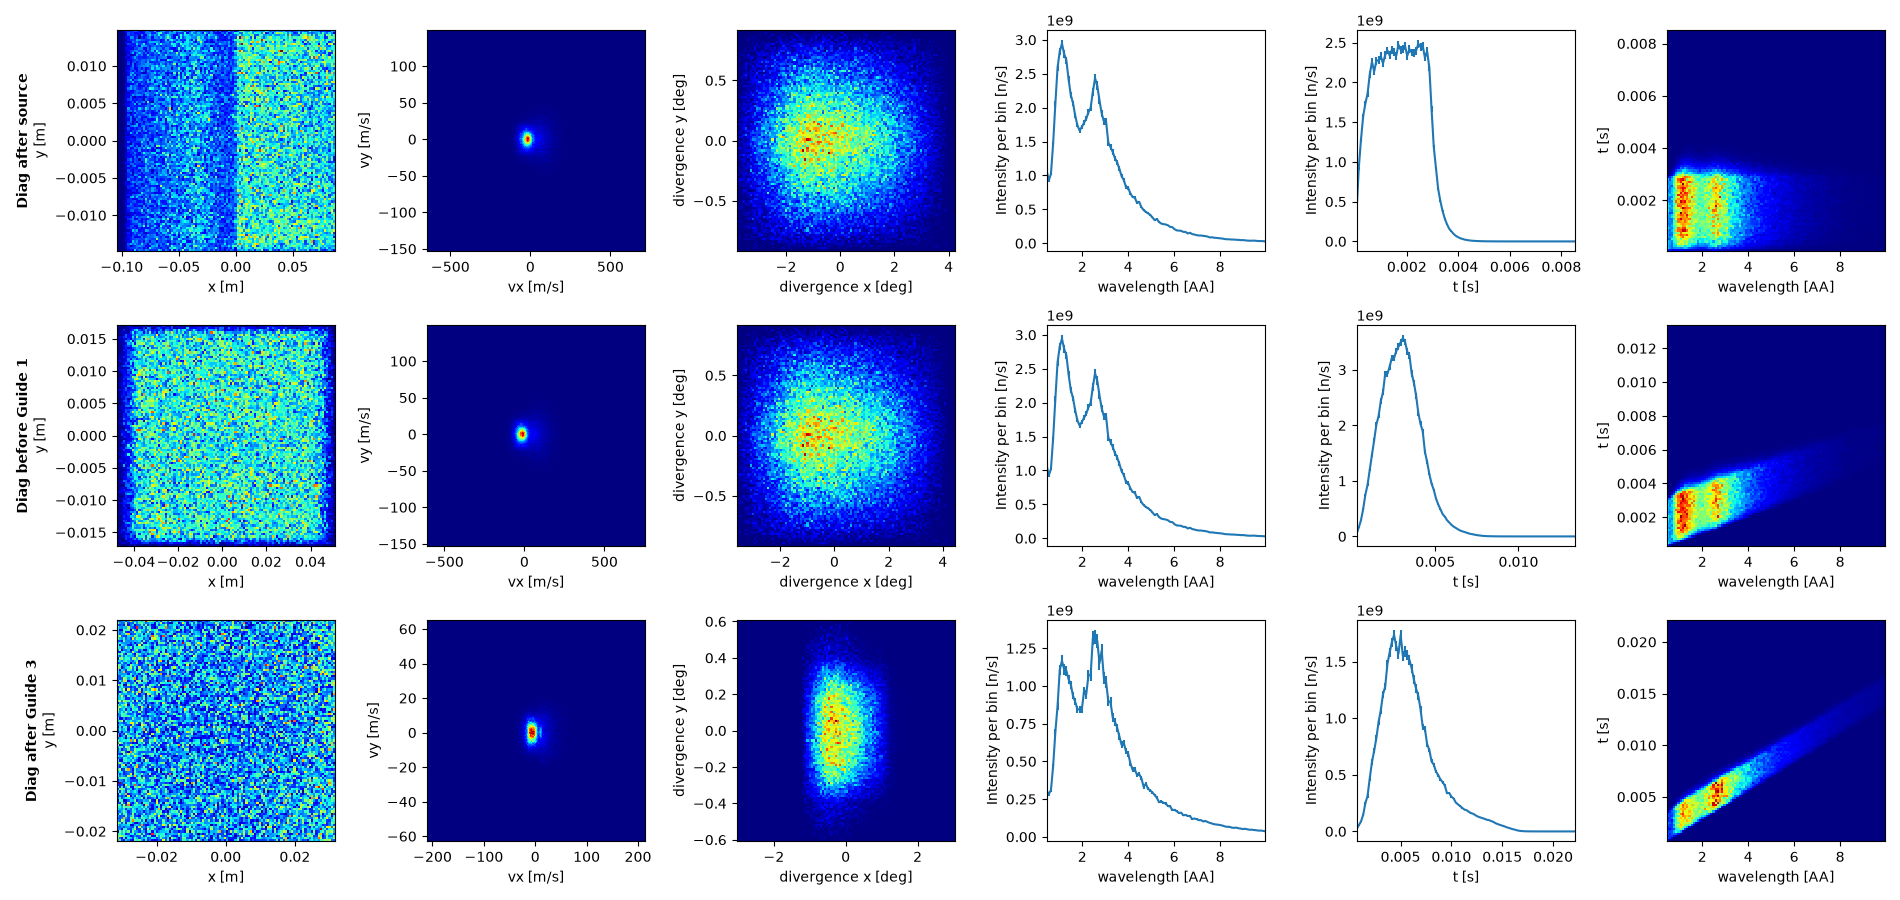

In [ ]:
diag.clear_views()
diag.add_view("x", "y", bins=100)
diag.add_view("vx", "vy", bins=200)
diag.add_view("dx", "dy", bins=100)
diag.add_view("l", bins=100)
diag.add_view("t", bins=100)
diag.add_view("l", "t", bins=100)

%matplotlib widget
diag.plot()